In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_theme(style="whitegrid")

print("Loading the ML-ready dataset...")
df = pd.read_csv('../data/processed/bkk_cleaned.csv')

# Ensure our ML target is numeric
df['seconds_to_next_stop'] = pd.to_numeric(df['seconds_to_next_stop'], errors='coerce')
df['speed_kmh'] = pd.to_numeric(df['vehicle.position.speed'], errors='coerce') * 3.6 # Convert m/s to km/h

print(f"Loaded {len(df)} records.")

Loading the ML-ready dataset...
Loaded 13702 records.


1. The Target Distribution

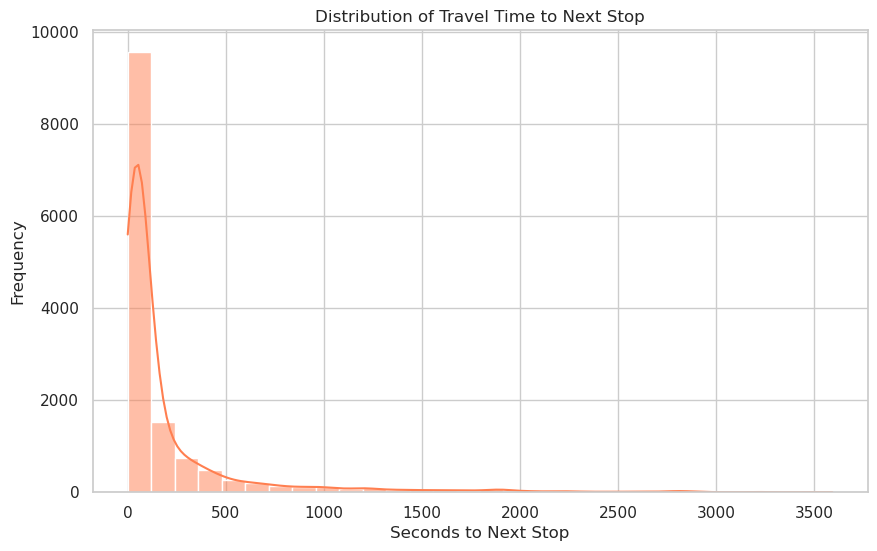

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['seconds_to_next_stop'], bins=30, kde=True, color='coral')
plt.title('Distribution of Travel Time to Next Stop')
plt.xlabel('Seconds to Next Stop')
plt.ylabel('Frequency')
plt.show()

2. The Physics Correlation

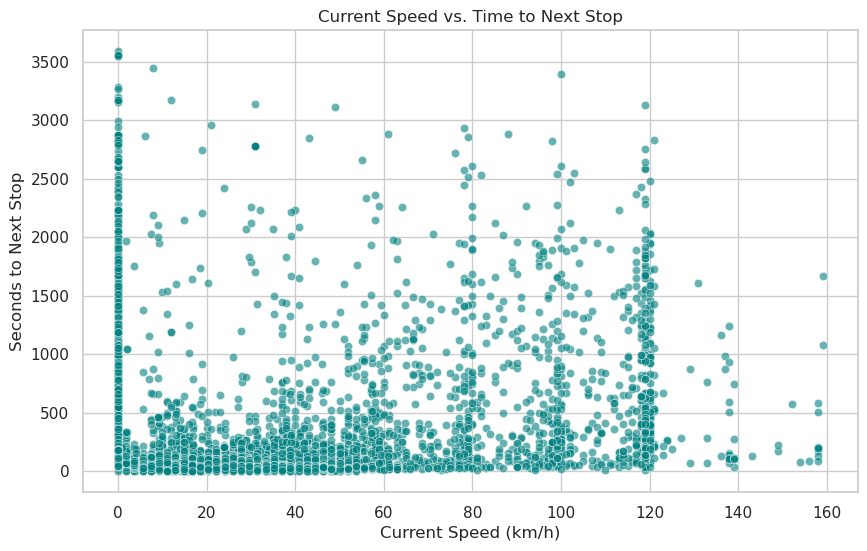

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='speed_kmh', y='seconds_to_next_stop', data=df, alpha=0.6, color='teal')
plt.title('Current Speed vs. Time to Next Stop')
plt.xlabel('Current Speed (km/h)')
plt.ylabel('Seconds to Next Stop')
plt.show()

In [14]:
# Plotly library usage example
import plotly.express as px

fig = px.scatter(
    df, 
    x='speed_kmh', 
    y='seconds_to_next_stop', 
    title='Current Speed vs. Time to Next Stop',
    labels={
        'speed_kmh': 'Current Speed (km/h)',         # Your custom X-axis label
        'seconds_to_next_stop': 'Seconds to Next Stop' # Your custom Y-axis label
    },
    opacity=0.6,
    color_discrete_sequence=['teal'],
    height=400 
)

fig.show()

3. The Geographic Heatmap

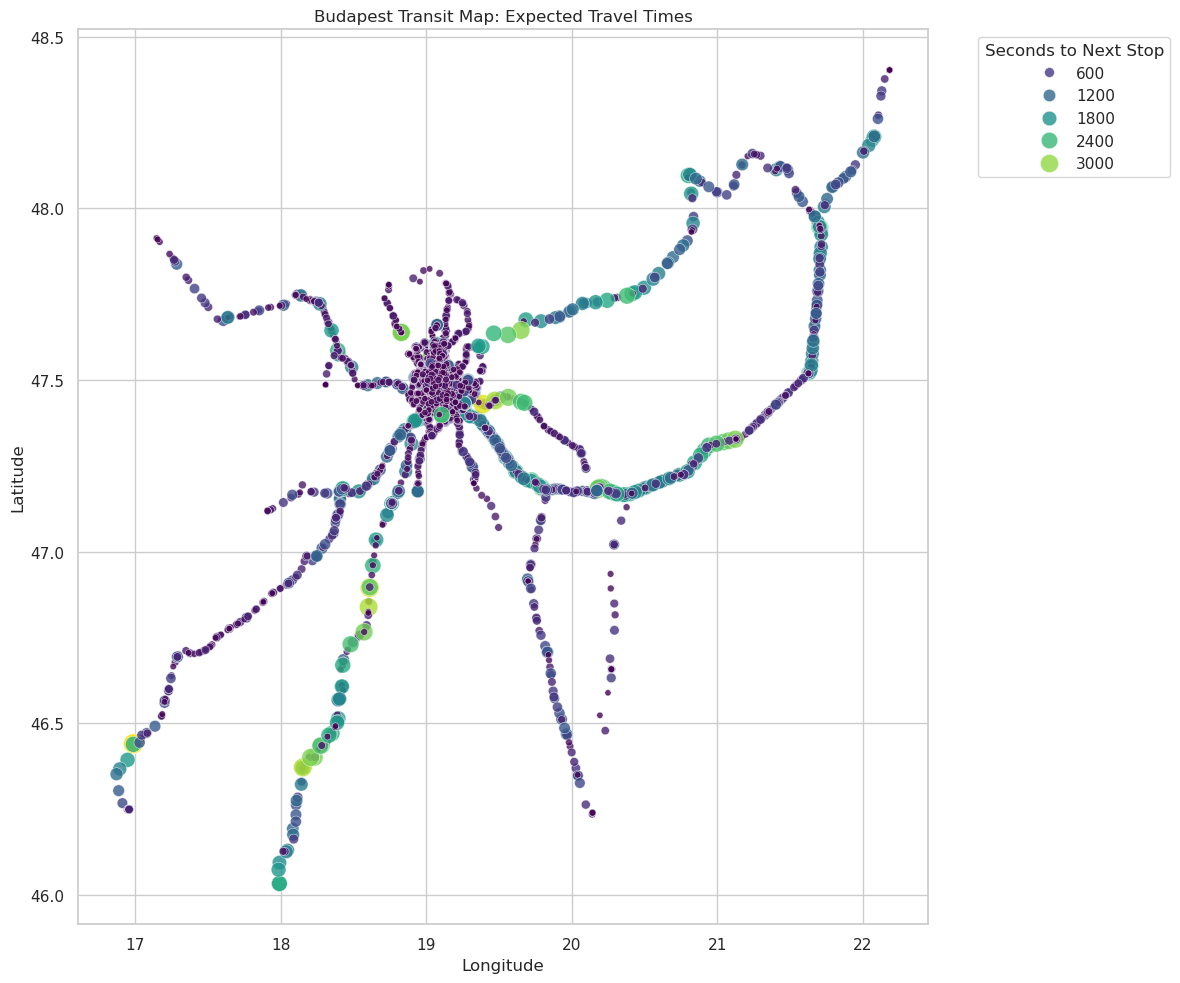

In [15]:
plt.figure(figsize=(12, 10))

# Use the exact column names generated by json_normalize
sns.scatterplot(
    x='vehicle.position.longitude', 
    y='vehicle.position.latitude', 
    hue='seconds_to_next_stop', 
    palette='viridis', 
    data=df, 
    size='seconds_to_next_stop', 
    sizes=(20, 200), 
    alpha=0.8
)

plt.title('Budapest Transit Map: Expected Travel Times')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Seconds to Next Stop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4. The "Status" Box Plot

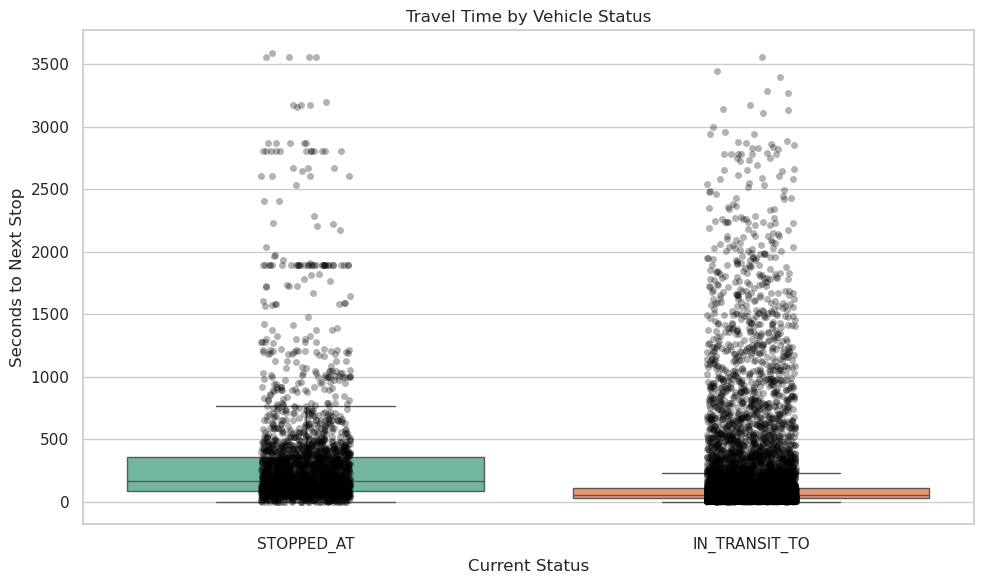

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Draw the boxplot
# Draw the boxplot
sns.boxplot(
    data=df, 
    x='vehicle.currentStatus', 
    y='seconds_to_next_stop',
    hue='vehicle.currentStatus',  # <-- Added this
    palette='Set2',
    showfliers=False,
    legend=False                  # <-- Added this
)

# Overlay the individual data points
sns.stripplot(
    data=df, 
    x='vehicle.currentStatus', 
    y='seconds_to_next_stop',
    color='black',
    alpha=0.3,
    jitter=True
)

plt.title('Travel Time by Vehicle Status')
plt.xlabel('Current Status')
plt.ylabel('Seconds to Next Stop')
plt.tight_layout()
plt.show()

5. The "Worst Routes" Bar Chart

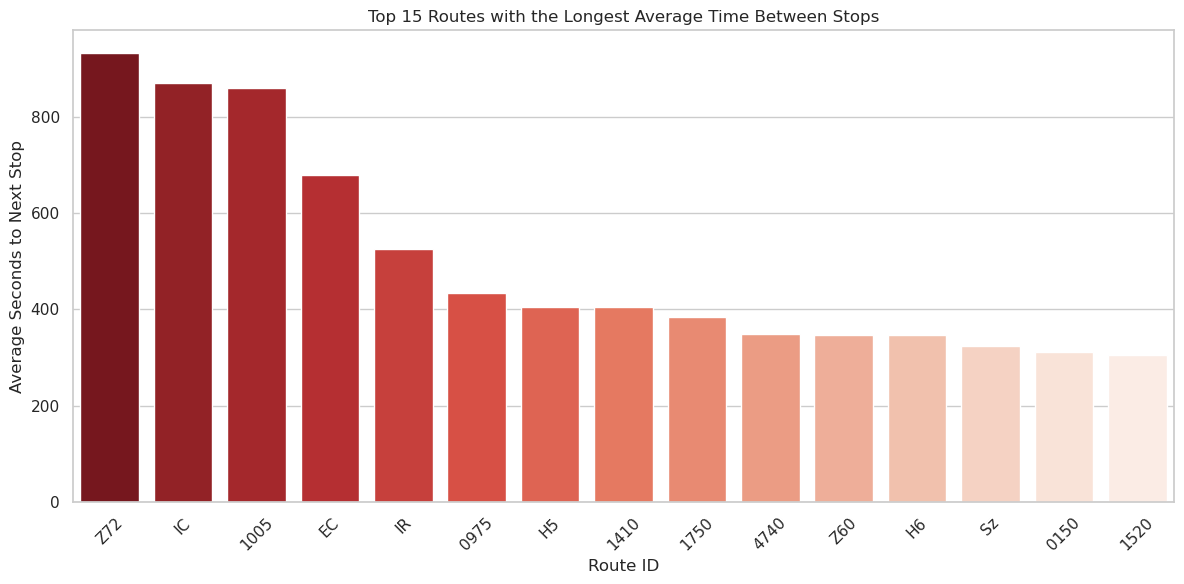

In [20]:
# Calculate the average time to next stop for every route
route_stats = df.groupby('vehicle.trip.routeId')['seconds_to_next_stop'].mean().reset_index()

# Sort to find the 15 slowest routes
top_slowest = route_stats.sort_values(by='seconds_to_next_stop', ascending=False).head(15)

plt.figure(figsize=(12, 6))
# We use palette='Reds_r' to make the longest times the darkest red
sns.barplot(
    data=top_slowest, 
    x='vehicle.trip.routeId', 
    y='seconds_to_next_stop',
    hue='vehicle.trip.routeId',   # <-- Added this
    palette='Reds_r',
    order=top_slowest['vehicle.trip.routeId'],
    legend=False                  # <-- Added this
)

plt.title('Top 15 Routes with the Longest Average Time Between Stops')
plt.xlabel('Route ID')
plt.ylabel('Average Seconds to Next Stop')
plt.xticks(rotation=45) # Tilt the route IDs so they don't overlap
plt.tight_layout()
plt.show()

6. The "Cascading Delay" Scatter Map

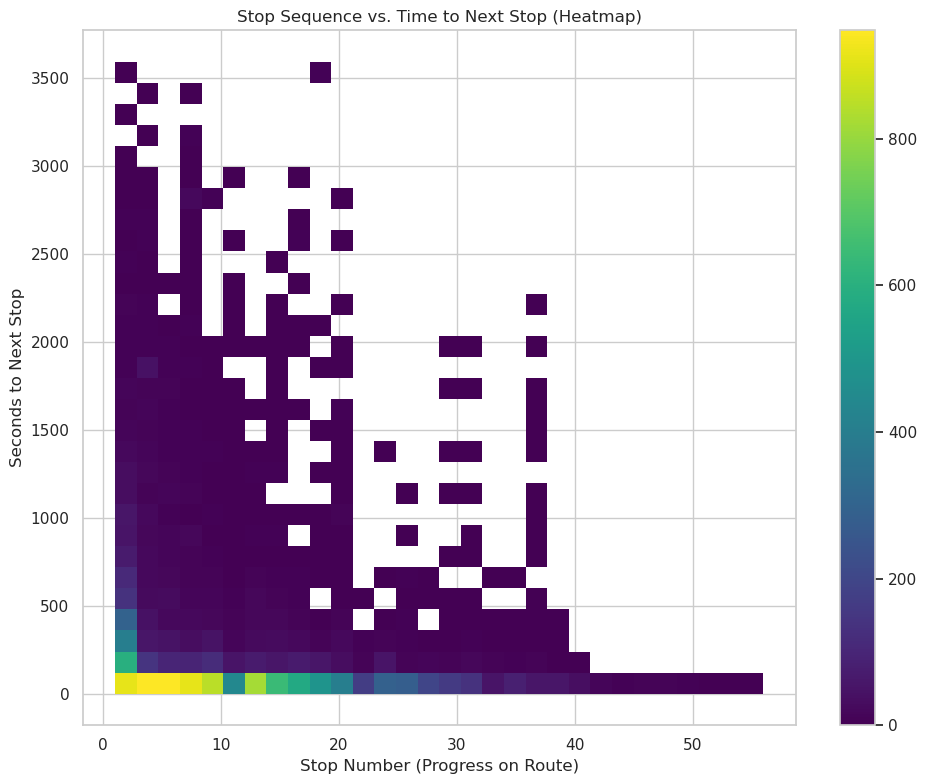

In [22]:
plt.figure(figsize=(10, 8))

# Passing both x and y to histplot creates a 2D Heatmap
sns.histplot(
    data=df, 
    x='vehicle.currentStopSequence', 
    y='seconds_to_next_stop',
    bins=30,
    cmap='viridis',
    cbar=True, # Add the colorbar legend on the right
    pmax=0.9   # Cap the color scale slightly to make the lighter points more visible
)

plt.title('Stop Sequence vs. Time to Next Stop (Heatmap)')
plt.xlabel('Stop Number (Progress on Route)')
plt.ylabel('Seconds to Next Stop')
plt.tight_layout()
plt.show()